<a href="https://colab.research.google.com/github/Eliezer-Carvalho/IP/blob/master/IP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

###### ter


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

#Esta class serve como implementação de um modelo SLM de 4 Biliões de Parâmetros hospedado localmente
#O modelo tem rodado na CPU, o que não é ideal mas tudo bem
#O modelo é o Qwen 3-4B -> https://huggingface.co/Qwen/Qwen3-4B-Base
#O código foi comentado para melhor compreensão global

#Problemas a solucionar -> O modelo carrega os dados sempre que é chamado, o que não é ideal. (SOLUCIONADO! VIA GOOGLE COLAB)
#Aplicar Quantização para diminuir o tamanho do modelo, ajuda na VRAM


class IP_MODEL ():

    def __init__(self, MODELO_PATH, PROMPT):

        self.tokenizer = AutoTokenizer.from_pretrained (MODELO_PATH) #Tokenizer
        self.MODELO = AutoModelForCausalLM.from_pretrained (MODELO_PATH, device_map = "cpu") #Modelo em si #device_map é onde o modelo roda

        self.PROMPT = PROMPT #Self instância do prompt

    def forward(self):


        inputs = self.tokenizer (self.PROMPT, return_tensors = 'pt') #Tokenização do Input do Utilizador #return_tensors = 'pt' usa py torch tensors (padrão da indústria)
        probs = self.MODELO.generate (**inputs, max_new_tokens = 100) #Geração com max_new_tokens
        text = self.tokenizer.decode (probs[0]) #Decode token a token por isso o [0]
        return text


teste = IP_MODEL (r"C:\Users\eliez\Desktop\ip\Modelos\Qwen3-4 Base", "Olá, fala-me sobre as Infraestruturas de Portugal")
print (teste.forward())


#### **Weights Loader**

In [2]:
def Qwen4B (modelo):

  MODEL = AutoModelForCausalLM.from_pretrained (modelo).to(device)
  return MODEL

#### **Inferência do Modelo**

In [16]:
def Infer (modelo, prompt, MODEL):

  tokenizer = AutoTokenizer.from_pretrained (modelo)

  inputs = tokenizer (prompt, return_tensors = 'pt').to(device)

  with torch.no_grad():
    probs = MODEL (**inputs) #Prompt Processing

  output_tokens = MODEL.generate (**inputs, max_new_tokens = 100) #Token Generation

  text = tokenizer.decode (output_tokens [0])

#### **Main**

In [4]:
modelo = 'Qwen/Qwen3-4B-Base'

weights_loader = Qwen4B (modelo)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

In [17]:
Infer (modelo, "Fala-me da Infraestruturas de Portugal", weights_loader)

torch.Size([1, 11])
2


Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


Fala-me da Infraestruturas de Portugal
A Infraestruturas de Portugal (IP) é uma empresa pública portuguesa que desempenha um papel crucial na gestão e operação de infraestruturas de transporte e comunicação no país. Fundada em 1999, a IP tem como missão principal garantir a eficiência, a segurança e a sustentabilidade das infraestruturas que sustentam a economia e a sociedade portuguesa.

### Principais
torch.Size([1, 11])
2


Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


Fala-me da Infraestruturas de Portugal
A Infraestruturas de Portugal (IP) é uma empresa pública portuguesa que desempenha um papel crucial na gestão e operação de infraestruturas de transporte e comunicação no país. Fundada em 1999, a IP tem como missão principal garantir a eficiência, a segurança e a sustentabilidade das infraestruturas que sustentam a economia e a sociedade portuguesa.

### Principais
torch.Size([1, 11])
2


...

Fala-me da Infraestruturas de Portugal
A Infraestruturas de Portugal (IP) é uma empresa pública portuguesa que desempenha um papel crucial na gestão e operação de infraestruturas de transporte e comunicação no país. Fundada em 1999, a IP tem como missão principal garantir a eficiência, a segurança e a sustentabilidade das infraestruturas que sustentam a economia e a sociedade portuguesa.

### Principais
torch.Size([1, 11])
2


Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


Fala-me da Infraestruturas de Portugal
A Infraestruturas de Portugal (IP) é uma empresa pública portuguesa que desempenha um papel crucial na gestão e operação de infraestruturas de transporte e comunicação no país. Fundada em 1999, a IP tem como missão principal garantir a eficiência, a segurança e a sustentabilidade das infraestruturas que sustentam a economia e a sociedade portuguesa.

### Principais
torch.Size([1, 11])
2


Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


Fala-me da Infraestruturas de Portugal
A Infraestruturas de Portugal (IP) é uma empresa pública portuguesa que desempenha um papel crucial na gestão e operação de infraestruturas de transporte e comunicação no país. Fundada em 1999, a IP tem como missão principal garantir a eficiência, a segurança e a sustentabilidade das infraestruturas que sustentam a economia e a sociedade portuguesa.

### Principais


In [ ]:
model = AutoModelForCausalLM.from_pretrained (modelo)
print (model.config)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Qwen3Config {
  "architectures": [
    "Qwen3ForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "dtype": "bfloat16",
  "eos_token_id": 151643,
  "head_dim": 128,
  "hidden_act": "silu",
  "hidden_size": 2560,
  "initializer_range": 0.02,
  "intermediate_size": 9728,
  "layer_types": [
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    

#### **Quantização**


In [1]:
import matplotlib.pyplot as plt

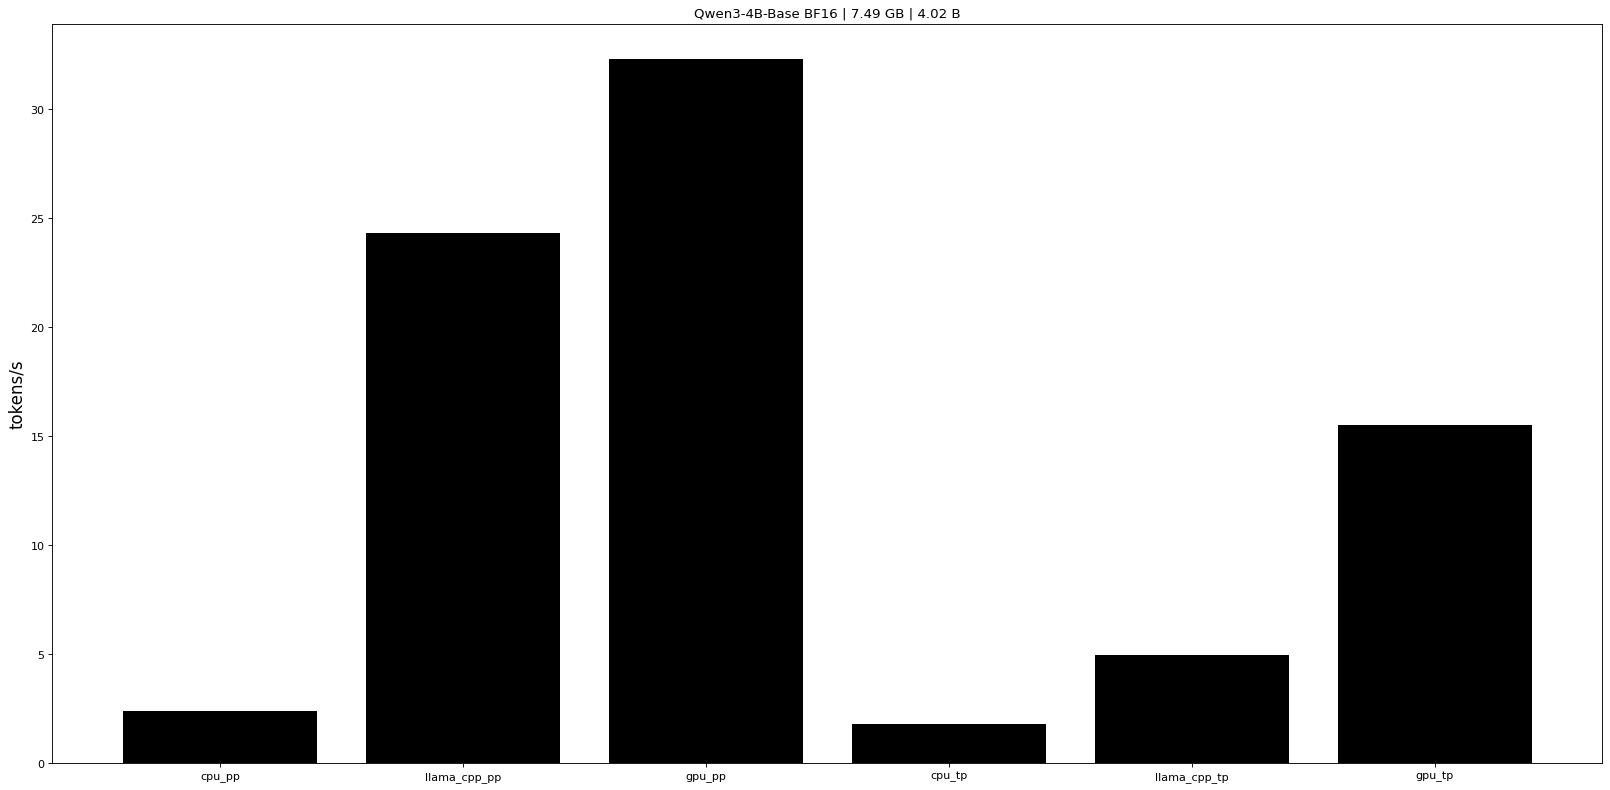

In [16]:
QWEN = {

    "cpu_pp": 2.39,
    "llama_cpp_pp": 24.33,
    "gpu_pp": 32.3,

    "cpu_tp": 1.79,
    "llama_cpp_tp": 4.95,
    "gpu_tp": 15.5
}


plt.figure (figsize = (25, 12), dpi = 80)
plt.bar (QWEN.keys(), QWEN.values(), color = "black")

plt.ylabel ("tokens/s", size = 15)

plt.title ("Qwen3-4B-Base BF16 | 7.49 GB | 4.02 B")
plt.show()